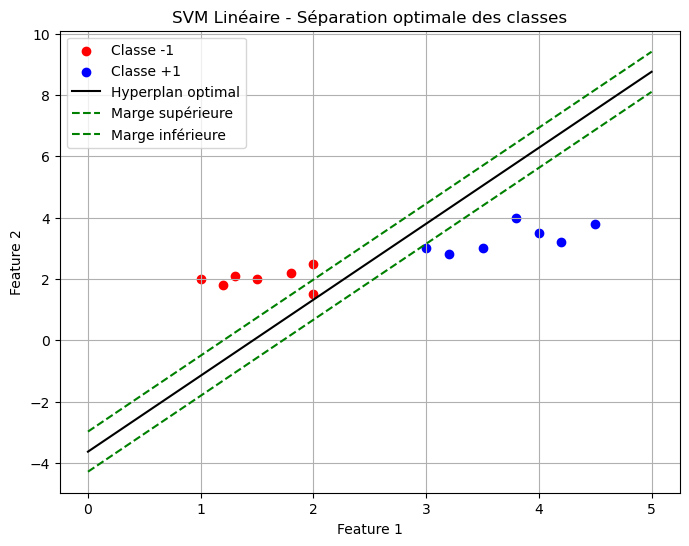

In [9]:
#BOUTAINA AHNACH ;  MASTER:GLCC
import numpy as np
import matplotlib.pyplot as plt

# =========================================================
# 1. CONSTRUCTION DU DATASET
# =========================================================
# On travaille sur un problème de classification supervisée binaire.
# Chaque point représente une observation dans un espace 2D.
# Le but est de séparer les deux classes avec une frontière optimale.

# Classe négative (-1)
# Ces points représentent une région du plan appartenant à la classe -1
X_neg = np.array([
    [1, 2], [1.5, 2], [2, 2.5], [1.2, 1.8], [2, 1.5],
    [1.8, 2.2], [1.3, 2.1]
])

# Classe positive (+1)
# Ces points représentent une autre région du plan appartenant à la classe +1
X_pos = np.array([
    [3, 3], [3.5, 3], [4, 3.5], [3.2, 2.8], [4.2, 3.2],
    [3.8, 4], [4.5, 3.8]
])

# Labels associés aux classes
# -1 : classe négative
# +1 : classe positive
y_neg = -np.ones(len(X_neg))
y_pos = np.ones(len(X_pos))

# Fusion des données pour former le dataset final
X = np.vstack((X_neg, X_pos))
y = np.hstack((y_neg, y_pos))


# =========================================================
# 2. PRINCIPE DU SVM
# =========================================================
# Le SVM cherche un hyperplan défini par :
#       w · x + b = 0
#
# Objectif :
# - Séparer les deux classes
# - Maximiser la marge entre elles
#
# Les points les plus proches de la frontière sont appelés :
# → vecteurs de support

class SVM:

    def __init__(self, lr=0.001, lambda_param=0.01, n_iters=1000):

        # lr (learning rate) :
        # contrôle la vitesse d'adaptation du modèle
        # un taux trop élevé peut empêcher la convergence

        self.lr = lr

        # lambda_param (régularisation) :
        # empêche les poids de devenir trop grands
        # cela améliore la généralisation du modèle

        self.lambda_param = lambda_param

        # n_iters :
        # nombre d'itérations pour optimiser les paramètres
        self.n_iters = n_iters

        # w :
        # vecteur normal à l'hyperplan
        # définit l'orientation de la séparation
        self.w = None

        # b :
        # biais (permet de déplacer la frontière)
        self.b = None

    # =========================================================
    # 3. APPRENTISSAGE (OPTIMISATION)
    # =========================================================
    def fit(self, X, y):

        # nombre d'exemples et de features
        n_samples, n_features = X.shape

        # initialisation des paramètres à zéro
        self.w = np.zeros(n_features)
        self.b = 0

        # boucle principale d'apprentissage
        for _ in range(self.n_iters):

            # on parcourt chaque point du dataset
            for idx, x_i in enumerate(X):

                # =================================================
                # CONDITION FONDAMENTALE DU SVM
                # =================================================
                # y_i (w · x_i + b) ≥ 1
                #
                # Interprétation :
                # - ≥ 1 → point bien classé et hors marge
                # - < 1 → point mal classé ou dans la marge

                condition = y[idx] * (np.dot(x_i, self.w) - self.b) >= 1

                # =================================================
                # CAS 1 : POINT CORRECTEMENT CLASSÉ
                # =================================================
                if condition:

                    # On ne corrige pas l'erreur de classification
                    # mais on applique la régularisation L2
                    #
                    # Objectif : minimiser ||w|| pour maximiser la marge

                    self.w -= self.lr * (2 * self.lambda_param * self.w)

                # =================================================
                # CAS 2 : POINT MAL CLASSÉ
                # =================================================
                else:

                    # Le point est mal classé ou trop proche de la frontière
                    # On ajuste donc les paramètres pour corriger l'erreur

                    # mise à jour du vecteur w
                    self.w -= self.lr * (
                        2 * self.lambda_param * self.w
                        - np.dot(x_i, y[idx])
                    )

                    # mise à jour du biais b
                    # permet de déplacer la frontière pour mieux séparer les classes
                    self.b -= self.lr * y[idx]

    # =========================================================
    # 4. PRÉDICTION
    # =========================================================
    def predict(self, X):

        # fonction de décision :
        # w · x + b

        # si > 0 → classe +1
        # sinon → classe -1

        linear_output = np.dot(X, self.w) - self.b

        return np.sign(linear_output)


# =========================================================
# 5. ENTRAÎNEMENT DU MODÈLE
# =========================================================
model = SVM()
model.fit(X, y)


# =========================================================
# 6. VISUALISATION GRAPHIQUE
# =========================================================
plt.figure(figsize=(8,6))

# affichage des points de la classe -1
plt.scatter(X_neg[:, 0], X_neg[:, 1], color='red', label='Classe -1')

# affichage des points de la classe +1
plt.scatter(X_pos[:, 0], X_pos[:, 1], color='blue', label='Classe +1')

# =========================================================
# FRONTIÈRE DE DÉCISION
# =========================================================
# équation : w1*x + w2*y + b = 0
# on isole y pour obtenir une droite

x1 = np.linspace(0, 5, 100)
x2 = -(model.w[0] * x1 - model.b) / model.w[1]

# tracé de l'hyperplan
plt.plot(x1, x2, 'k-', label='Hyperplan optimal')

# =========================================================
# MARGES DU SVM
# =========================================================
# la marge représente la distance entre les deux frontières parallèles
# autour de l'hyperplan principal

margin = 1 / np.linalg.norm(model.w)

plt.plot(x1, x2 + margin, 'g--', label='Marge supérieure')
plt.plot(x1, x2 - margin, 'g--', label='Marge inférieure')

# =========================================================
# FINALISATION DU GRAPHIQUE
# =========================================================
plt.title("SVM Linéaire - Séparation optimale des classes")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.legend()
plt.grid(True)

plt.show()